### Import library

In [85]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
import os
import shap
import pickle
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)


### Load dataset 

In [86]:
df = pd.read_csv('../dataset/data/train.csv')
df.head(20)

,Timestamp,Open,High,Low,Close,Volume
0,1.553935e+09,4071.17,4071.17,4067.74,4067.74,4.587708
1,1.539865e+09,6431.90,6432.91,6429.81,6432.91,5.358719
2,1.379555e+09,127.96,127.96,127.80,127.80,0.457695
3,1.762841e+09,105322.00,105322.00,105266.00,105267.00,0.339559
4,1.446742e+09,385.77,386.92,385.76,386.92,22.224000
5,1.700457e+09,37354.00,37354.00,37354.00,37354.00,15.626177
6,1.340119e+09,6.47,6.47,6.47,6.47,0.000000
7,1.539675e+09,6433.49,6433.49,6428.79,6428.79,3.068286
8,1.720013e+09,60554.00,60558.00,60529.00,60529.00,0.697651
9,1.727068e+09,63877.00,63877.00,63683.00,63683.00,9.207357


### Time Conversion & Resampling:

In [87]:
# ubah timestamp ke datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'].astype(int), unit='s')

# set sebagai index (wajib untuk time series)
df.set_index('Timestamp', inplace=True)

data = df['Close']

data.head()

Timestamp
2019-03-30 08:38:00      4067.74
2018-10-18 12:24:00      6432.91
2013-09-19 01:45:00       127.80
2025-11-11 05:58:00    105267.00
2015-11-05 16:39:00       386.92
Name: Close, dtype: float64

In [88]:
data = data.resample('1h').mean().dropna()

#### Missing Data Imputation:

In [89]:
df.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [90]:
print("Data Training")
df.describe()

Data Training


,Open,High,Low,Close,Volume
count,6.012038e+06,6.012038e+06,6.012038e+06,6.012038e+06,6.012038e+06
mean,2.275733e+04,2.276539e+04,2.274909e+04,2.275735e+04,5.050939e+00
std,3.096599e+04,3.097441e+04,3.095750e+04,3.096602e+04,2.189686e+01
min,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00
25%,4.517900e+02,4.519700e+02,4.515500e+02,4.517900e+02,2.120705e-02
50%,7.719400e+03,7.723890e+03,7.714195e+03,7.719500e+03,4.573510e-01
75%,3.613171e+04,3.615650e+04,3.610400e+04,3.613189e+04,2.853782e+00
max,1.261980e+05,1.262390e+05,1.261580e+05,1.262020e+05,5.853852e+03


### Stationarity Audit:

In [91]:
hasil = adfuller(data)

print("ADF Statistic:", hasil[0])
print("p-value:", hasil[1])
print("Critical Values:")
for key, value in hasil[4].items():
    print(f"{key}: {value}")

ADF Statistic: -0.6386821633850991
p-value: 0.8619997402390778
Critical Values:
1%: -3.430402240246844
5%: -2.8615630894218396
10%: -2.566782289682375


### Temporal Transformation

In [92]:
data_diff = data.diff().dropna()

hasil_diff = adfuller(data_diff)

print("p-value setelah differencing:", hasil_diff[1])

p-value setelah differencing: 0.0


### Autocorrelation Check:

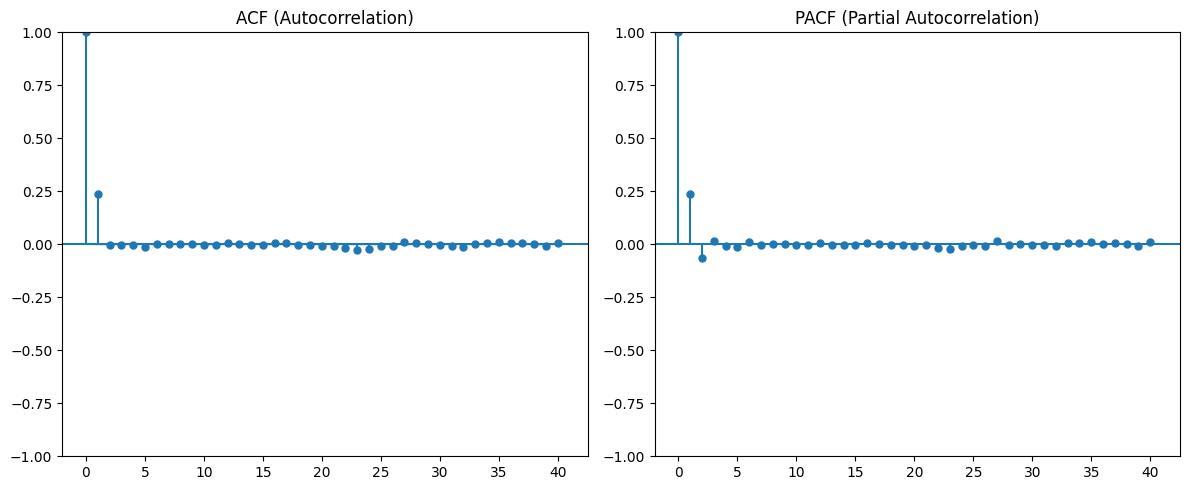

In [93]:


# gunakan data yang SUDAH stasioner (hasil differencing)
plt.figure(figsize=(12,5))

# ACF
plt.subplot(1,2,1)
plot_acf(data_diff, lags=40, ax=plt.gca())
plt.title('ACF (Autocorrelation)')

# PACF
plt.subplot(1,2,2)
plot_pacf(data_diff, lags=40, ax=plt.gca(), method='ywm')
plt.title('PACF (Partial Autocorrelation)')

plt.tight_layout()
plt.show()

### Scalling data 

In [94]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data.values.reshape(-1, 1))

### Membuat Sequence

In [95]:
def create_dataset(data, time_step=24, future_step=7):  # Input 24 jam, output 7 jam
    X, y = [], []
    # Loop disesuaikan agar indeks data target tidak melampaui panjang dataset
    for i in range(len(data) - time_step - future_step + 1):
        X.append(data[i : i+time_step])
        # Mengambil potongan sequence sepanjang future_step setelah time_step
        y.append(data[i+time_step : i+time_step+future_step])
    return np.array(X), np.array(y)

TIME_STEP = 24
FUTURE_STEP = 7  # Ubah nilai ini untuk menentukan berapa jam ke depan yang ingin diprediksi sekaligus
X, y = create_dataset(scaled_data, TIME_STEP, FUTURE_STEP)

X.shape, y.shape


((125223, 24, 1), (125223, 7, 1))

### Split data

In [96]:

X_train = X
y_train = y

### Build Model LSTM

In [97]:
from tensorflow.keras.layers import RepeatVector, TimeDistributed

def build_model(units=50, dropout=0.2, future_step=7):
    model = Sequential()
    # --- ENCODER ---
    model.add(Input(shape=(TIME_STEP, 1)))
    model.add(LSTM(units, return_sequences=False)) # Meringkas info sequence input
    model.add(Dropout(dropout))
    
    # --- BRIDGE ---
    # Mengulang output encoder sebanyak future_step (misal 7 kali)
    model.add(RepeatVector(future_step)) 
    
    # --- DECODER ---
    model.add(LSTM(units, return_sequences=True)) # Menghasilkan sequence output
    
    # Menerapkan layer Dense(1) ke setiap timestep dari decoder output secara paralel
    model.add(TimeDistributed(Dense(1))) 
    
    model.compile(optimizer='adam', loss='mse')
    return model


In [98]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### Tuning

In [99]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

best_val_loss = float("inf")
best_model = None
best_params = None

for units in [32, 50, 64]:
    for dropout in [0.1, 0.2]:

        K.clear_session()
        print(f"\n[INFO] Memulai training dengan: Units={units}, Dropout={dropout}...")

        model = build_model(units, dropout) 

        history = model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=20,
            batch_size=64,
            callbacks=[early_stop],
            verbose=1 
        )

        val_loss = min(history.history['val_loss'])

        print(
            f"--> SELESAI: Units={units}, "
            f"Dropout={dropout}, "
            f"Val Loss Terbaik={val_loss:.6f}"
        )
        print("-" * 50)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model
            best_params = {
                "units": units,
                "dropout": dropout
            }

print("\n===== BEST MODEL =====")
print("Units      :", best_params["units"])
print("Dropout    :", best_params["dropout"])
print("Val Loss   :", best_val_loss)



[INFO] Memulai training dengan: Units=32, Dropout=0.1...
Epoch 1/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - loss: 2.5946e-04 - val_loss: 0.0180
Epoch 2/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 4.4408e-05 - val_loss: 0.0321
Epoch 3/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 3.8336e-05 - val_loss: 0.0386
Epoch 4/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 3.4796e-05 - val_loss: 0.0254
Epoch 5/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 3.2479e-05 - val_loss: 0.0329
Epoch 6/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 3.1961e-05 - val_loss: 0.0284
--> SELESAI: Units=32, Dropout=0.1, Val Loss Terbaik=0.017958
--------------------------------------------------

[INFO] Memulai training dengan: Units=32, Dropout=0.2...
Epoch 1/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - loss: 2.9360e-04 - val_loss: 0.0446
Epoch 2/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 7.0165e-05 - val_loss: 0.0410
Epoch 3/20
1566/156

In [100]:
# Simpan model
best_model.save("../model/lstm_forecasting.keras")

# Simpan scaler
with open("../model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model dan scaler berhasil disimpan")

Model dan scaler berhasil disimpan


### SHAP

100%|██████████| 10/10 [03:37<00:00, 21.79s/it]


Shape SHAP values : (10, 24, 7)
Shape Sample data : (10, 24)


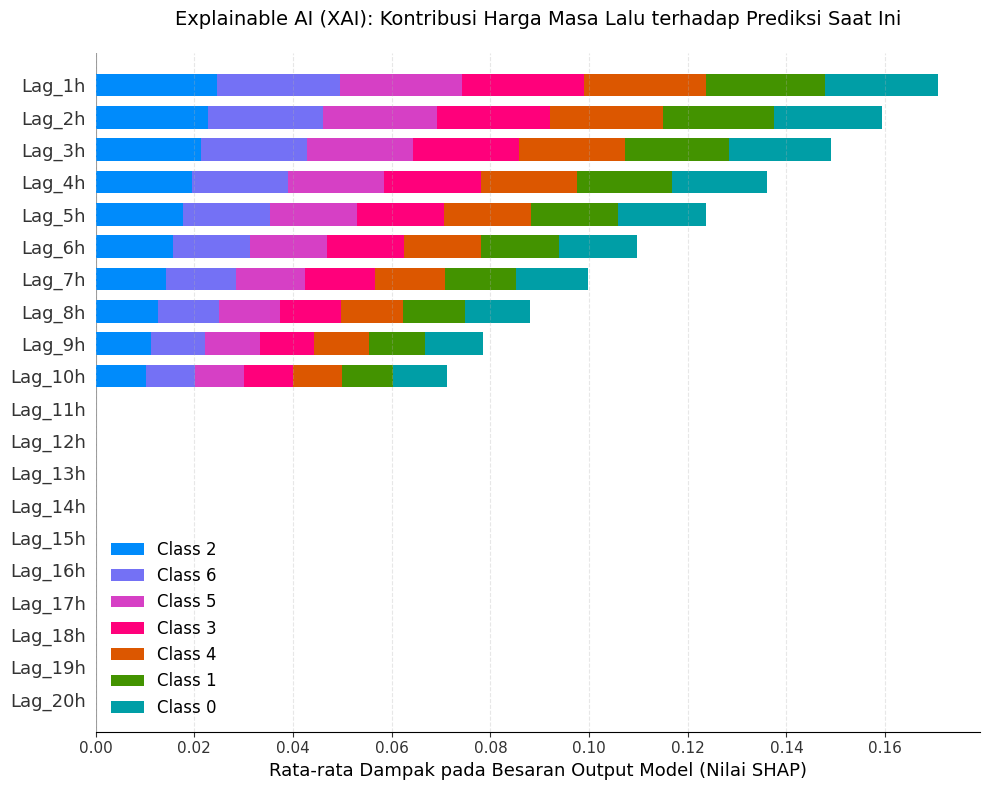

In [101]:
# 1. Define Feature Names (Pengaruh 24 jam ke belakang)
feature_names = [f'Lag_{24-i}h' for i in range(24)]

# 2. Prepare Data
# Flatten X_train menjadi 2D untuk SHAP (samples, features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Gunakan shap.sample agar pemilihan background data lebih representatif dan stabil
background_data = shap.sample(X_train_flat, 50) 
sample_data = X_train_flat[:10]

# 3. Wrapper untuk Model LSTM (Disesuaikan untuk Output Multi-Step / Many-to-Many)
def predict_wrapper(x):
    # Kembalikan ke bentuk 3D (samples, timesteps, features) untuk input LSTM
    x_3d = x.reshape(x.shape[0], 24, 1)
    preds = best_model.predict(x_3d, verbose=0)
    
    # Jika output berbentuk 3D (samples, future_step, 1), ubah ke 2D (samples, future_step)
    if len(preds.shape) == 3:
        preds = preds.reshape(preds.shape[0], -1)
        
    return preds

# 4. Hitung SHAP values dengan KernelExplainer
explainer = shap.KernelExplainer(predict_wrapper, background_data)
shap_values = explainer.shap_values(sample_data)

# 5. Penanganan Dimensi yang Aman
# KernelExplainer kadang mengembalikan List (jika multi-output), kita ambil elemen pertamanya
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# Pastikan shap_values adalah numpy array 2D
shap_values = np.array(shap_values)

print("Shape SHAP values :", shap_values.shape)
print("Shape Sample data :", sample_data.shape)

# 6. Visualisasi Plot
plt.clf() # Membersihkan kanvas sebelumnya (mencegah plot kosong)

# Generate plot tanpa menampilkan langsung (show=False)
shap.summary_plot(
    shap_values,
    sample_data,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

# Kustomisasi Figure Matplotlib SETELAH plot SHAP dibuat
fig = plt.gcf()
fig.set_size_inches(10, 8) # Atur ukuran di sini
plt.title("Explainable AI (XAI): Kontribusi Harga Masa Lalu terhadap Prediksi Saat Ini", fontsize=14, pad=20)
plt.xlabel("Rata-rata Dampak pada Besaran Output Model (Nilai SHAP)")
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

# Tampilkan plot
plt.show()


In [102]:
model = load_model("../model/lstm_forecasting.keras")

with open("../model/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print("Model dan scaler berhasil dimuat")

Model dan scaler berhasil dimuat


In [103]:
# %%
test_df = pd.read_csv("../dataset/BTCUSDT_30d.csv")

print(test_df.head())
print(test_df.shape)

       Timestamp      open      high       low     close    volume
0  1779186480000  76821.70  76821.70  76821.69  76821.70   0.83701
1  1779186540000  76821.70  76837.55  76821.70  76837.54  10.06699
2  1779186600000  76837.54  76848.72  76837.54  76848.70   7.10209
3  1779186660000  76848.71  76888.53  76848.71  76888.52   2.74171
4  1779186720000  76888.52  76910.41  76880.00  76910.41   7.76370
(43200, 6)


In [104]:
print("Data Test")
test_df.describe()

Data Test


,Timestamp,open,high,low,close,volume
count,4.320000e+04,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000
mean,1.780482e+12,69187.349480,69208.648047,69165.928179,69187.051714,13.124527
std,7.482546e+08,6078.416463,6072.049537,6084.522986,6078.359473,25.974552
min,1.779186e+12,59153.520000,59285.720000,59130.910000,59153.510000,0.081430
25%,1.779834e+12,63538.267500,63558.635000,63517.217500,63538.270000,2.978852
50%,1.780482e+12,66862.690000,66892.925000,66840.000000,66862.655000,6.349935
75%,1.781130e+12,75519.562500,75526.020000,75509.105000,75519.255000,13.724132
max,1.781778e+12,78173.150000,78200.000000,78147.530000,78173.150000,1110.299710


In [105]:
# %%
# Ubah timestamp (milidetik) menjadi datetime
test_df['Timestamp'] = pd.to_datetime(
    test_df['Timestamp'].astype(int),
    unit='ms'  # Diubah dari 's' ke 'ms'
)

# Jadikan index
test_df.set_index('Timestamp', inplace=True)

# Ambil kolom close (huruf kecil)
data_test = test_df['close']  # Diubah dari 'Close' ke 'close'

# Resampling 1 jam
data_test = data_test.resample('1h').mean().dropna()

print(data_test.head())
print("Jumlah data:", len(data_test))


Timestamp
2026-05-19 10:00:00    76896.940625
2026-05-19 11:00:00    76871.279500
2026-05-19 12:00:00    76850.700500
2026-05-19 13:00:00    76827.177667
2026-05-19 14:00:00    76493.349833
Freq: h, Name: close, dtype: float64
Jumlah data: 721


In [ ]:
scaled_test = scaler.transform(
    data_test.values.reshape(-1,1)
)

print(scaled_test.shape)

(721, 1)


In [107]:
def create_dataset_test(data, time_step=24, future_step=7):
    X = []
    y = []
    # Loop disesuaikan dengan future_step
    for i in range(len(data) - time_step - future_step + 1):
        X.append(data[i:i+time_step])
        # Mengambil target 7 langkah ke depan
        y.append(data[i+time_step : i+time_step+future_step])

    return np.array(X), np.array(y)

TIME_STEP = 24
FUTURE_STEP = 7 # Samakan dengan model training Anda

X_test, y_test = create_dataset_test(
    scaled_test,
    TIME_STEP,
    FUTURE_STEP
)

print("X_test shape :", X_test.shape) # Output yang benar: (samples, 24, 1)
print("y_test shape :", y_test.shape) # Output yang benar: (samples, 7, 1)


X_test shape : (691, 24, 1)
y_test shape : (691, 7, 1)


In [ ]:
y_pred_scaled = model.predict(X_test)

print(y_pred_scaled.shape)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
(691, 7, 1)


In [109]:
# 1. Reshape y_pred_scaled dari 3D ke 2D untuk inverse scaling, lalu kembalikan ke 2D (samples, future_step)
y_pred_flat = y_pred_scaled.reshape(-1, 1)
y_pred = scaler.inverse_transform(y_pred_flat).reshape(y_pred_scaled.shape[0], -1)

# 2. Lakukan hal yang sama untuk y_test (aktual)
y_test_flat = y_test.reshape(-1, 1)
y_actual = scaler.inverse_transform(y_test_flat).reshape(y_test.shape[0], -1)

print("Shape Actual:", y_actual.shape) # Akan menghasilkan (samples, future_step)
print("Shape Pred  :", y_pred.shape)   # Akan menghasilkan (samples, future_step)


Shape Actual: (691, 7)
Shape Pred  : (691, 7)


In [110]:
print("\nPrediksi Pertama")

for i in range(len(y_actual)):
    print(
        f"Actual={y_actual[i][0]:.2f} | "
        f"Pred={y_pred[i][0]:.2f}"
    )



Prediksi Pertama
Actual=77574.33 | Pred=75832.24
Actual=77456.73 | Pred=75891.32
Actual=77505.71 | Pred=75934.01
Actual=77315.32 | Pred=75977.81
Actual=77349.00 | Pred=75998.52
Actual=77514.23 | Pred=76020.27
Actual=77315.44 | Pred=76054.23
Actual=77501.01 | Pred=76064.23
Actual=77502.91 | Pred=76090.26
Actual=77532.35 | Pred=76112.74
Actual=77665.40 | Pred=76135.42
Actual=77653.86 | Pred=76168.16
Actual=77412.21 | Pred=76196.16
Actual=77467.62 | Pred=76198.45
Actual=77738.53 | Pred=76205.27
Actual=77923.53 | Pred=76236.38
Actual=77969.35 | Pred=76281.37
Actual=78001.30 | Pred=76326.73
Actual=78018.31 | Pred=76371.59
Actual=77901.68 | Pred=76414.09
Actual=77735.46 | Pred=76440.95
Actual=77668.91 | Pred=76448.94
Actual=77981.49 | Pred=76448.85
Actual=77827.31 | Pred=76477.43
Actual=77452.77 | Pred=76486.88
Actual=77274.78 | Pred=76459.21
Actual=77226.68 | Pred=76416.36
Actual=77151.76 | Pred=76370.64
Actual=77034.50 | Pred=76320.02
Actual=77180.13 | Pred=76261.03
Actual=77180.26 | Pred

In [ ]:
mae = mean_absolute_error(
    y_actual,
    y_pred
)

mse = mean_squared_error(
    y_actual,
    y_pred
)

rmse = np.sqrt(mse)

mape = mean_absolute_percentage_error(
    y_actual,
    y_pred
)

r2 = r2_score(
    y_actual,
    y_pred
)

print("R2 Score:", r2)

print("="*40)
print("HASIL PENGUJIAN DATA TEST")
print("="*40)
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAPE :", mape)

R2 Score: 0.961366451711562
HASIL PENGUJIAN DATA TEST
MAE  : 956.8458393060188
MSE  : 1389305.02850076
RMSE : 1178.687841839713
MAPE : 0.013498458723929532


In [112]:
# %%
n = len(y_actual)

k = model.count_params()

aic = n * np.log(mse) + 2 * k

bic = n * np.log(mse) + k * np.log(n)

print("AIC :", aic)
print("BIC :", bic)

AIC : 109743.7211126005
BIC : 336582.6402036275


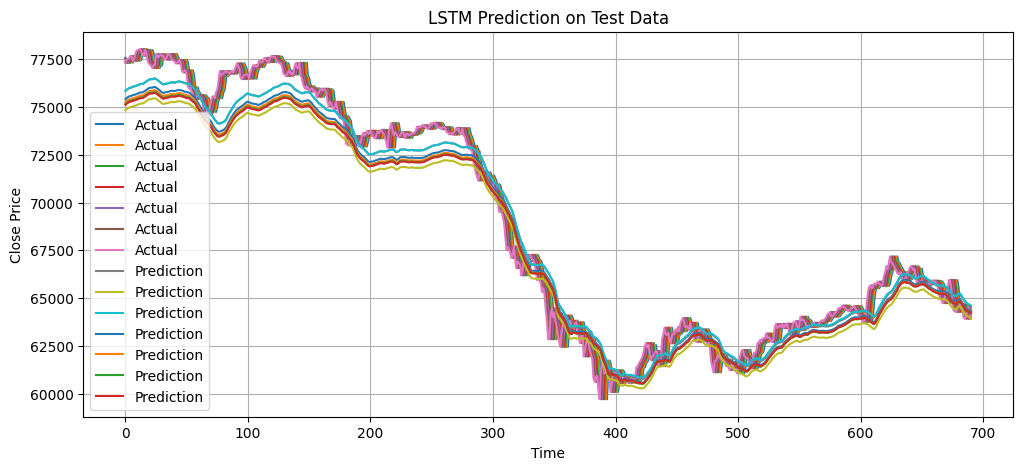

In [113]:
# %%
plt.figure(figsize=(12,5))

plt.plot(
    y_actual,
    label="Actual"
)

plt.plot(
    y_pred,
    label="Prediction"
)

plt.title("LSTM Prediction on Test Data")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.legend()

plt.grid(True)

plt.show()

In [115]:
import numpy as np

# Gunakan 'scaler' (bukan scaler_forecast) dan 'data' (setelah cell atas dijalankan)
scaled_data_forecast = scaler.transform(data.values.reshape(-1, 1))

# Ambil 24 data terakhir sebagai sequence awal
TIME_STEP = 24
last_sequence = scaled_data_forecast[-TIME_STEP:]

# Prediksi untuk 7 hari ke depan (7 * 24 jam = 168 jam)
forecast_steps = 7 * 24
FUTURE_STEP = 7  
forecast_list = []

# Reshape sequence awal
current_sequence = last_sequence.reshape(1, TIME_STEP, 1)

# Jumlah perulangan
iterations = forecast_steps // FUTURE_STEP

print(f"Memulai prediksi {forecast_steps} jam ke depan (dalam {iterations} langkah)...")
for i in range(iterations):
    # Gunakan 'model' (bukan model_forecast)
    next_pred = model.predict(current_sequence, verbose=0)
    
    next_pred_flat = next_pred.flatten()
    forecast_list.extend(next_pred_flat)
    
    next_pred_reshaped = next_pred_flat.reshape(1, FUTURE_STEP, 1)
    current_sequence = np.append(current_sequence[:, FUTURE_STEP:, :], next_pred_reshaped, axis=1)

print("Proses prediksi selesai.")


Memulai prediksi 168 jam ke depan (dalam 24 langkah)...
Proses prediksi selesai.


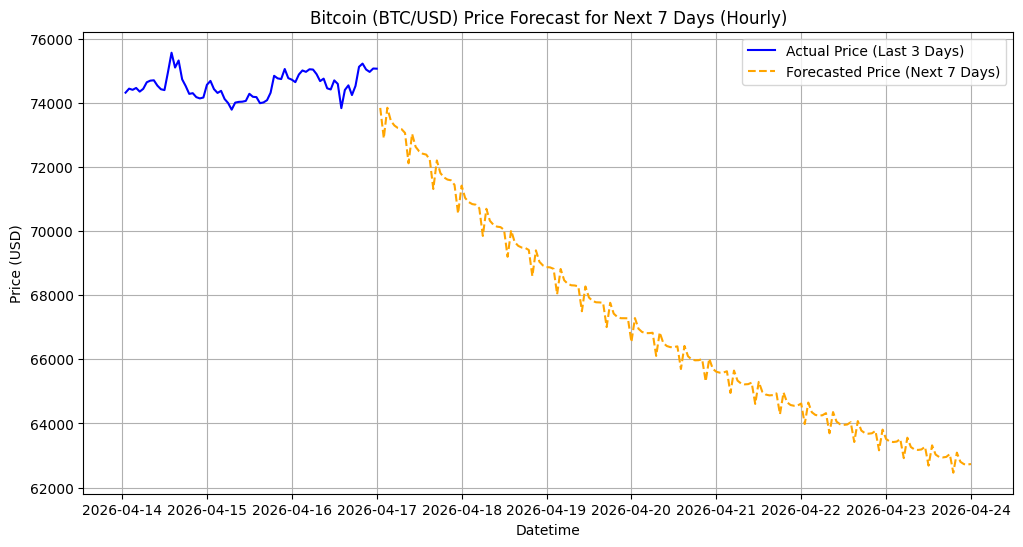

Preview Hasil Forecast:
                     Forecasted_Close
2026-04-17 01:00:00      73837.515625
2026-04-17 02:00:00      72892.695312
2026-04-17 03:00:00      73843.007812
2026-04-17 04:00:00      73434.171875
2026-04-17 05:00:00      73289.421875
2026-04-17 06:00:00      73209.968750
2026-04-17 07:00:00      73178.781250
2026-04-17 08:00:00      73058.898438
2026-04-17 09:00:00      72111.898438
2026-04-17 10:00:00      73028.960938


In [117]:
import pandas as pd
import matplotlib.pyplot as plt

# Kembalikan skala hasil prediksi ke harga USD asli
forecast_list = np.array(forecast_list).reshape(-1, 1)
forecast_prices = scaler_forecast.inverse_transform(forecast_list)

# Buat index datetime untuk 168 jam ke depan mulai dari timestamp terakhir data aktual
last_timestamp = data.index[-1]
forecast_timestamps = pd.date_range(
    start=last_timestamp + pd.Timedelta(hours=1), 
    periods=forecast_steps, 
    freq='h'
)

# Gabungkan hasil ke dalam DataFrame
df_forecast = pd.DataFrame(data=forecast_prices, index=forecast_timestamps, columns=['Forecasted_Close'])

# Visualisasi Hasil Forecast 7 Hari ke Depan
plt.figure(figsize=(12, 6))
# Plot data aktual 3 hari terakhir agar grafik terlihat tersambung secara historis
plt.plot(data.tail(24 * 3), label='Actual Price (Last 3 Days)', color='blue')
# Plot hasil prediksi 7 hari ke depan
plt.plot(df_forecast['Forecasted_Close'], label='Forecasted Price (Next 7 Days)', color='orange', linestyle='--')
plt.title("Bitcoin (BTC/USD) Price Forecast for Next 7 Days (Hourly)")
plt.xlabel("Datetime")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Tampilkan preview 10 hasil prediksi pertama
print("Preview Hasil Forecast:")
print(df_forecast.head(10))
